# Experiment: Pre-Training vs. Specialization for Time Series Prediction

## Overview
This experiment compares the effectiveness of pre-training on diverse generators versus specializing on limited data from an unkown target generator, that we can't sample from at will, for predicting the last value of a time series.

### Target Generator
- The target generator produces time series sampled from a normal distribution: `g ~ N(5, 10)`.
- Each time series has a fixed length of 50: `s = [s_1, s_2, ..., s_50]`.
- The goal is to predict the final value `s_50` using the first 49 values `[s_1, s_2, ..., s_49]`.

### Datasets
1. **Dataset A (Specialized Training):**
   - Contains a limited number `n` of time series sampled directly from the target generator `g`.
   - Represents training on limited specialized data.

2. **Dataset B (Pre-Training Data):**
   - Contains time series sampled from multiple alternative generators, each with similar structure (length 50) but different distributions (e.g., `N(0, 5)`, `N(10, 15)`).
   - Represents training on diverse data from unrelated generators.

### Evaluation
- Models will be evaluated on their ability to predict `s_50` for unseen time series sampled from the target generator `g`.

---

## Hypotheses
1. **Pre-Training Hypothesis:**
   - Pre-training on diverse generators will allow the model to learn general time series prediction principles.
   - Fine-tuning on limited data from `g` will improve performance further.
   - This approach may outperform specialized training on limited data.

2. **Specialization Hypothesis:**
   - A model trained exclusively on data from `g` (even if limited) will perform better because it directly focuses on the target distribution.

---

## Models
We will compare the following models:
1. **Model A (Specialized Training):**  
   Trained only on Dataset A, which is limited data from the target generator `g`.

2. **Model B (Pre-Training):**  
   Trained only on Dataset B, which is data from alternative generators.

3. **Model C (Pre-Training + Fine-Tuning):**  
   Pre-trained on Dataset B and then fine-tuned on Dataset A.

---

## Experiment Steps
1. **Data Generation:**
   - Generate time series data from `g` for both training (Dataset A) and testing.
   - Generate time series data from multiple alternative generators for pre-training (Dataset B).

2. **Model Training:**
   - Train **Model A** using Dataset A.
   - Train **Model B** using Dataset B.
   - Pre-train **Model C** on Dataset B, then fine-tune it on Dataset A.

3. **Evaluation:**
   - Test all models on out-of-sample data generated by `g`.
   - Measure performance using Mean Squared Error (MSE).

---

## Implementation Details
- **Model Type:** Neural Network (Regression).
- **Input:** First 49 values of the time series (`[s_1, s_2, ..., s_49]`).
- **Output:** Predicted value of `s_50`.
- **Loss Function:** Mean Squared Error (MSE).
- **Optimization:** Use standard regression training with appropriate hyperparameters.


In [1]:
import numpy as np
import pandas as pd

# Step 1: Data Generation

# Parameters
time_series_length = 50
num_samples_target = 1000  # Number of time series from the target generator, assume to be historically sampled from unknown generator
num_samples_pretraining = 100000  # Number of time series from alternative generators, assume to be sampled at will from known generators

# Target generator: N(5, 10)
def generate_target_series(num_samples):
    return np.random.normal(loc=5, scale=10, size=(num_samples, time_series_length))

# Function to generate data from 10 alternative generators
def generate_10_alternative_series(num_samples):
    # Define 10 different normal distributions
    generators = [
        np.random.normal(loc=0, scale=5, size=(num_samples // 10, time_series_length)),
        np.random.normal(loc=10, scale=15, size=(num_samples // 10, time_series_length)),
        np.random.normal(loc=20, scale=20, size=(num_samples // 10, time_series_length)),
        np.random.normal(loc=-10, scale=10, size=(num_samples // 10, time_series_length)),
        np.random.normal(loc=-20, scale=25, size=(num_samples // 10, time_series_length)),
        np.random.normal(loc=5, scale=8, size=(num_samples // 10, time_series_length)),
        np.random.normal(loc=-5, scale=12, size=(num_samples // 10, time_series_length)),
        np.random.normal(loc=15, scale=18, size=(num_samples // 10, time_series_length)),
        np.random.normal(loc=-15, scale=6, size=(num_samples // 10, time_series_length)),
        np.random.normal(loc=30, scale=10, size=(num_samples // 10, time_series_length))
    ]
    # Combine all generated data
    return np.vstack(generators)


# Generate datasets
target_data = generate_target_series(num_samples_target)
alternative_data = generate_10_alternative_series(num_samples_pretraining)

# Shuffle the dataset
np.random.shuffle(alternative_data)

# Convert to Pandas DataFrame for better organization
target_df = pd.DataFrame(target_data, columns=[f"s_{i+1}" for i in range(time_series_length)])
alternative_df = pd.DataFrame(alternative_data, columns=[f"s_{i+1}" for i in range(time_series_length)])


target_df.shape, alternative_df.shape


((1000, 50), (100000, 50))

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Data Preparation


# Split the target generator data into training and testing sets
X_target = target_df.iloc[:, :-1]  # Input: s_1 to s_49
y_target = target_df.iloc[:, -1]   # Output: s_50
X_train_target, X_test_target, y_train_target, y_test_target = train_test_split(X_target, y_target, test_size=0.3, random_state=42)

# Split the alternative generator data into training and validation sets
X_alternative = alternative_df.iloc[:, :-1]  # Input: s_1 to s_49
y_alternative = alternative_df.iloc[:, -1]   # Output: s_50

# Scale X data
target_scaler = StandardScaler()
X_train_target = target_scaler.fit_transform(X_train_target)
X_test_target = target_scaler.transform(X_test_target)

alternative_scaler = StandardScaler()
X_alternative = alternative_scaler.fit_transform(X_alternative)




# print shapes of the datasets
print("X_train_target shape:", X_train_target.shape)
print("y_train_target shape:", y_train_target.shape)
print("X_test_target shape:", X_test_target.shape)
print("y_test_target shape:", y_test_target.shape)

print("X_alternative shape:", X_alternative.shape)
print("y_alternative shape:", y_alternative.shape)




X_train_target shape: (700, 49)
y_train_target shape: (700,)
X_test_target shape: (300, 49)
y_test_target shape: (300,)
X_alternative shape: (100000, 49)
y_alternative shape: (100000,)


In [3]:
from sklearn.neural_network import MLPRegressor

# Model Training
print("Training models...")

# Model A: Train on target generator data
model_a = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=500, random_state=42)
model_a.fit(X_train_target, y_train_target)

print('Model A Trained')

# Model B: Train on alternative generators' data
model_b = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=500, random_state=42)
model_b.fit(X_alternative, y_alternative)

print('Model B Trained')

# Model C: Pre-train on alternative generators, fine-tune on target generator
model_c = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=500, random_state=42)
# Pre-train on alternative generators
model_c.fit(X_alternative, y_alternative)
# Fine-tune on target generator
model_c.partial_fit(X_train_target, y_train_target)

print('Model C Trained')

print("Training complete.")

Training models...


c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Model A Trained
Model B Trained
Model C Trained
Training complete.


In [4]:
from sklearn.metrics import mean_squared_error
# Evaluation

# Predict and evaluate on out-of-sample data from the target generator
y_pred_a = model_a.predict(X_test_target)
y_pred_b = model_b.predict(X_test_target)
y_pred_c = model_c.predict(X_test_target)

mse_a = mean_squared_error(y_test_target, y_pred_a)
mse_b = mean_squared_error(y_test_target, y_pred_b)
mse_c = mean_squared_error(y_test_target, y_pred_c)

# Print results
print("Model A (Trained on target generator): MSE =", mse_a)
print("Model B (Trained on alternative generators): MSE =", mse_b)
print("Model C (Pre-trained on alternative generators, fine-tuned on target generator): MSE =", mse_c)

Model A (Trained on target generator): MSE = 225.19219131582932
Model B (Trained on alternative generators): MSE = 102.25359788482594
Model C (Pre-trained on alternative generators, fine-tuned on target generator): MSE = 102.13256647762105



#### Interpretation
1. **Value of Pre-Training:**
   - The results show the potential value of pre-training when we cannot sample from the target generator at will.  
   - Model B (pre-trained on alternative generators) outperformed Model A (trained only on the target generator's limited samples), indicating that pre-training on a diverse dataset can generalize well to unseen target data.

2. **Impact of Alternative Generators:**
   - A key factor in this success is the selection of alternative generators, which were all normal distributions similar to the "unknown" target generator and covered a similar parameter range.
   - Based on the logic of pre-training with the same data structure \( D \) and a similar probability distribution \( P(x, y) \), the alternative generators effectively occupied a subspace around the surface \( P_g \).  
   - This allowed the generalized model (Model B) to capture the specifics of the target generator \( g \), even outperforming a specialized model trained only on limited samples (Model A).

3. **Fine-Tuning:**
   - Fine-tuning (Model C) did not significantly improve performance over pre-training alone (Model B).  
   - This suggests that the target dataset was too small to add substantial value or that the generalized model already captured most of the target generator's characteristics during pre-training.

---

#### Open Questions
1. **Generality Across More Complex Generators:**
   - Will this approach work equally well with more complex and diverse generators that differ significantly from the target generator?

2. **Threshold for Specialization:**
   - Is there a threshold for the target dataset size (or the ratio between dataset sizes) at which specialization becomes better than pre-training?

---

#### Potential Next Steps
To further explore these questions:
1. Experiment with more complex and diverse generators (e.g., time series with non-Gaussian distributions, non-linear dependencies).
2. Vary the size of the target dataset to determine if there is a critical threshold where specialization surpasses pre-training.
3. Analyze the impact of alternative generators that are less similar to the target generator.
4. Test other neural network architectures (e.g., RNNs or Transformers) to evaluate if the observed trends hold across more expressive models.


In [7]:
# multiple runs
n_runs = 10

mse_a_list = []
mse_b_list = []
mse_c_list = []

for i in range(n_runs):
    print(f"Run {i+1}/{n_runs}")
    # Generate datasets
    target_data = generate_target_series(num_samples_target)
    alternative_data = generate_10_alternative_series(num_samples_pretraining)

    # Shuffle the dataset
    np.random.shuffle(alternative_data)

    # Convert to Pandas DataFrame for better organization
    target_df = pd.DataFrame(target_data, columns=[f"s_{i+1}" for i in range(time_series_length)])
    alternative_df = pd.DataFrame(alternative_data, columns=[f"s_{i+1}" for i in range(time_series_length)])

    # Split the target generator data into training and testing sets
    X_target = target_df.iloc[:, :-1]  # Input: s_1 to s_49
    y_target = target_df.iloc[:, -1]   # Output: s_50
    X_train_target, X_test_target, y_train_target, y_test_target = train_test_split(X_target, y_target, test_size=0.3, random_state=42)

    # Split the alternative generator data into training and validation sets
    X_alternative = alternative_df.iloc[:, :-1]  # Input: s_1 to s_49
    y_alternative = alternative_df.iloc[:, -1]   # Output: s_50

    # Scale X data
    target_scaler = StandardScaler()
    X_train_target = target_scaler.fit_transform(X_train_target)
    X_test_target = target_scaler.transform(X_test_target)

    alternative_scaler = StandardScaler()
    X_alternative = alternative_scaler.fit_transform(X_alternative)

    # Model Training
    model_a = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=500, random_state=42)
    model_a.fit(X_train_target, y_train_target)

    model_b = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=500, random_state=42)
    model_b.fit(X_alternative, y_alternative)

    model_c = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=500, random_state=42)
    model_c.fit(X_alternative, y_alternative)

    model_c.partial_fit(X_train_target, y_train_target)

    # Evaluation
    y_pred_a = model_a.predict(X_test_target)
    y_pred_b = model_b.predict(X_test_target)
    y_pred_c = model_c.predict(X_test_target)

    mse_a = mean_squared_error(y_test_target, y_pred_a)
    mse_b = mean_squared_error(y_test_target, y_pred_b)
    mse_c = mean_squared_error(y_test_target, y_pred_c)

    mse_a_list.append(mse_a)
    mse_b_list.append(mse_b)
    mse_c_list.append(mse_c)

# Print results
print("Model A (Trained on target generator): Mean MSE =", np.mean(mse_a_list))
print("Model B (Trained on alternative generators): Mean MSE =", np.mean(mse_b_list))
print("Model C (Pre-trained on alternative generators, fine-tuned on target generator): Mean MSE =", np.mean(mse_c_list))

# Print standard deviation
print("Model A (Trained on target generator): Standard Deviation =", np.std(mse_a_list))
print("Model B (Trained on alternative generators): Standard Deviation =", np.std(mse_b_list))
print("Model C (Pre-trained on alternative generators, fine-tuned on target generator): Standard Deviation =", np.std(mse_c_list))



Run 1/10


c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Run 2/10


c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Run 3/10


...

Run 9/10


c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Run 10/10


c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Model A (Trained on target generator): Mean MSE = 171.73291276967151
Model B (Trained on alternative generators): Mean MSE = 134.78162579351806
Model C (Pre-trained on alternative generators, fine-tuned on target generator): Mean MSE = 134.28080365295472
Model A (Trained on target generator): Standard Deviation = 12.255313577966414
Model B (Trained on alternative generators): Standard Deviation = 14.327109126549113
Model C (Pre-trained on alternative generators, fine-tuned on target generator): Standard Deviation = 14.033080308288962


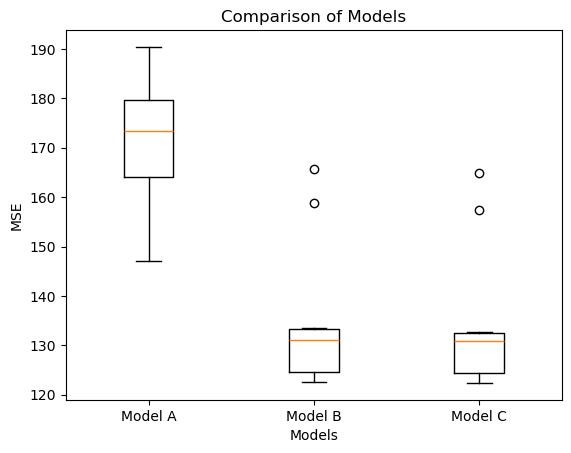

In [8]:
from matplotlib import pyplot as plt

# Box plot of MSE
plt.boxplot([mse_a_list, mse_b_list, mse_c_list])
plt.xticks([1, 2, 3], ['Model A', 'Model B', 'Model C'])
plt.xlabel('Models')
plt.ylabel('MSE')
plt.title('Comparison of Models')
plt.show()

In [ ]:
# run experiment with different number of samples
num_samples_target_list = [100, 500, 1000, 5000, 10000]
pre_training_multiplier = 100

for num_samples_target in num_samples_target_list:

    # multiple runs
    n_runs = 10

    mse_a_list = []
    mse_b_list = []
    mse_c_list = []

    for i in range(n_runs):
        print(f"Run {i+1}/{n_runs}")
        # Generate datasets
        target_data = generate_target_series(num_samples_target)
        alternative_data = generate_10_alternative_series(num_samples_target*pre_training_multiplier)

        # Shuffle the dataset
        np.random.shuffle(alternative_data)

        # Convert to Pandas DataFrame for better organization
        target_df = pd.DataFrame(target_data, columns=[f"s_{i+1}" for i in range(time_series_length)])
        alternative_df = pd.DataFrame(alternative_data, columns=[f"s_{i+1}" for i in range(time_series_length)])

        # Split the target generator data into training and testing sets
        X_target = target_df.iloc[:, :-1]  # Input: s_1 to s_49
        y_target = target_df.iloc[:, -1]   # Output: s_50
        X_train_target, X_test_target, y_train_target, y_test_target = train_test_split(X_target, y_target, test_size=0.3, random_state=42)

        # Split the alternative generator data into training and validation sets
        X_alternative = alternative_df.iloc[:, :-1]  # Input: s_1 to s_49
        y_alternative = alternative_df.iloc[:, -1]   # Output: s_50

        # Scale X data
        target_scaler = StandardScaler()
        X_train_target = target_scaler.fit_transform(X_train_target)
        X_test_target = target_scaler.transform(X_test_target)

        alternative_scaler = StandardScaler()
        X_alternative = alternative_scaler.fit_transform(X_alternative)

        # Model Training
        model_a = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=500, random_state=42)
        model_a.fit(X_train_target, y_train_target)

        model_b = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=500, random_state=42)
        model_b.fit(X_alternative, y_alternative)

        model_c = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=500, random_state=42)
        model_c.fit(X_alternative, y_alternative)

        model_c.partial_fit(X_train_target, y_train_target)

        # Evaluation
        y_pred_a = model_a.predict(X_test_target)
        y_pred_b = model_b.predict(X_test_target)
        y_pred_c = model_c.predict(X_test_target)

        mse_a = mean_squared_error(y_test_target, y_pred_a)
        mse_b = mean_squared_error(y_test_target, y_pred_b)
        mse_c = mean_squared_error(y_test_target, y_pred_c)

        mse_a_list.append(mse_a)
        mse_b_list.append(mse_b)
        mse_c_list.append(mse_c)    

    # Save results as dataframe in csv
    results = pd.DataFrame({
        'Model A (Trained on target generator)': mse_a_list,
        'Model B (Trained on alternative generators)': mse_b_list,
        'Model C (Pre-trained on alternative generators, fine-tuned on target generator)': mse_c_list
    })
    results.to_csv(f"../Code/Data/poc_pre-training/{num_samples_target}_{num_samples_target*pre_training_multiplier}.csv", index=False)





